# Iris Classification Practice

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/umyunsang/edu/blob/main/ComputerScience/03_ai-ml-data/quantum-ml/04.quantum-kernel-classification/01.iris-qsvm/day01_01_02_iris_logistic_regression_and_visualization_lab.ipynb)

이 노트북은 `/Users/um-yunsang/Downloads/1-1.py`와 `/Users/um-yunsang/Downloads/1-2.py`를 하나로 합친 Colab 실행용 Iris 실습입니다. 두 스크립트의 차이는 마지막 시각화 단계뿐이므로, 분류 실습 흐름 뒤에 petal length/petal width 산점도를 이어서 배치했습니다.

**대상**
- Iris 데이터셋으로 분류 모델 학습 흐름을 처음 실습하는 학습자
- Python 스크립트를 Colab 노트북 단계로 나누어 실행하려는 학습자

**학습 목표**
- Iris 데이터셋의 feature와 target 구조를 확인한다.
- train/test split으로 학습 데이터와 평가 데이터를 나눈다.
- Logistic Regression 모델을 학습하고 정확도를 계산한다.
- 새 꽃 샘플의 품종을 예측한다.
- petal length와 petal width를 산점도로 시각화한다.


## Outline

1. Import libraries
2. Load and inspect the Iris dataset
3. Split features and labels into train/test sets
4. Train a Logistic Regression model
5. Predict and evaluate accuracy
6. Predict a new flower sample
7. Visualize petal length and petal width


## 1. Import libraries

Colab 기본 런타임에는 이 실습에 필요한 `scikit-learn`과 `matplotlib`이 포함되어 있습니다. 별도 설치 셀은 두지 않습니다.


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


## 2. Load the dataset

`load_iris()`는 작은 분류 실습에 자주 쓰이는 내장 데이터셋을 반환합니다. 먼저 feature 이름과 target 이름을 확인합니다.


In [2]:
iris = load_iris()

print("=" * 50)
print("Iris Dataset Information")
print("=" * 50)

print("Feature Names")
print(iris.feature_names)

print("\nTarget Names")
print(iris.target_names)


Iris Dataset Information
Feature Names
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Names
['setosa' 'versicolor' 'virginica']


## 3. Inspect the first samples

처음 5개 feature 행과 label 값을 확인해 데이터의 형태를 파악합니다.


In [3]:
print("First 5 Features")
print(iris.data[:5])

print("\nFirst 5 Labels")
print(iris.target[:5])


First 5 Features
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

First 5 Labels
[0 0 0 0 0]


## 4. Separate features and labels

머신러닝 모델은 입력 feature `X`와 정답 label `y`를 따로 받습니다.


In [4]:
X = iris.data
y = iris.target

print("Feature Shape:", X.shape)
print("Label Shape:", y.shape)


Feature Shape: (150, 4)
Label Shape: (150,)


## 5. Split train and test data

학습에 사용할 데이터와 평가에 사용할 데이터를 나눕니다. `random_state=42`를 고정해 다시 실행해도 같은 분할이 나오도록 합니다.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("Train Data:", X_train.shape)
print("Test Data:", X_test.shape)


Train Data: (120, 4)
Test Data: (30, 4)


## 6. Create and train the model

`LogisticRegression`은 분류 문제의 기본 baseline으로 쓰기 좋습니다. Iris 데이터는 작기 때문에 짧은 시간 안에 학습됩니다.


In [6]:
model = LogisticRegression(max_iter=300)
model.fit(X_train, y_train)

print("Model Training Complete")


Model Training Complete


## 7. Predict and evaluate

테스트 데이터에 대해 예측을 수행하고, 실제 label과 비교해 정확도를 계산합니다.


In [7]:
pred = model.predict(X_test)
accuracy = accuracy_score(y_test, pred)

print("Prediction Result")
print(pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")


Prediction Result
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]

Accuracy: 100.0 %


## 8. Compare actual and predicted labels

아래 출력은 모델이 어떤 테스트 샘플을 맞히거나 틀렸는지 빠르게 비교하기 위한 단계입니다.


In [8]:
print("Actual Label")
print(y_test)

print("\nPredicted Label")
print(pred)


Actual Label
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]

Predicted Label
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


## 9. Predict a new flower

새로운 꽃의 네 가지 측정값을 넣어 품종을 예측합니다.


In [9]:
new_flower = [[5.1, 3.5, 1.4, 0.2]]

result = model.predict(new_flower)

print("New Flower Prediction")
print("Predicted Label:", result[0])
print("Flower Name:", iris.target_names[result[0]])


New Flower Prediction
Predicted Label: 0
Flower Name: setosa


## 10. Visualize petal length and petal width

`1-2.py`에서 추가된 시각화 단계입니다. 꽃잎 길이와 꽃잎 폭을 산점도로 나타내고, 색상으로 품종 class를 구분합니다.


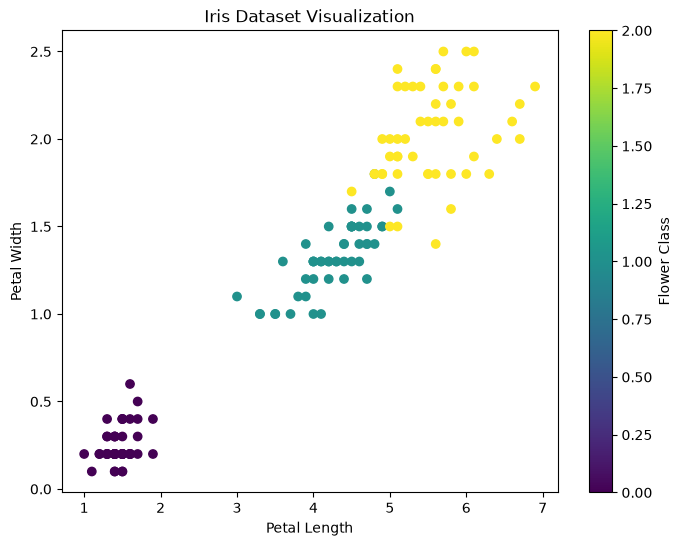

In [10]:
petal_length = iris.data[:, 2]
petal_width = iris.data[:, 3]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    petal_length,
    petal_width,
    c=iris.target,
    cmap="viridis",
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Dataset Visualization")
plt.colorbar(scatter, label="Flower Class")
plt.show()


## Wrap-up

이 노트북의 핵심 흐름은 `데이터 로드 -> 데이터 분리 -> 모델 학습 -> 예측 -> 평가 -> 시각화`입니다. 이후 실습에서는 같은 흐름을 유지하면서 모델, feature 선택, 평가 지표를 바꿔 비교할 수 있습니다.
